# 🪰 ffbf — Novelty Detection on a Semantic Stream

This notebook demonstrates the **Fruit Fly Bloom Filter** on real sentence embeddings.
We feed it a stream of tech sentences, watch novelty collapse as patterns become familiar,
then introduce a cuisine sentence to trigger a spike — and finally let the filter drift and forget.

> **Three acts:** learn tech → detect the intruder → drift to cuisine with passive forgetting.

## § 1 — Setup

In [1]:
# %pip install sentence-transformers matplotlib  # uncomment if needed

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from sentence_transformers import SentenceTransformer
from ffbf import FFBF, FFBFConfig, DecayMode, TickShape
from ffbf.viz import (
    plot_novelty_scores,
    plot_weight_state,
    plot_weight_evolution,
    plot_embedding_3d,
)

matplotlib.rcParams["figure.dpi"] = 120

model = SentenceTransformer("all-MiniLM-L6-v2")

cfg = FFBFConfig.default_for(input_dim=384, expected_n=50)
cfg.delta = 0.4
cfg.decay_mode = DecayMode.EdgeAndFront
cfg.tick_shape = TickShape.Exp
cfg.tick_rate = 0.02
cfg.seed = 42

f = FFBF(cfg)
m = len(f.weights())
print(f"Filter ready — {m} KC→MBON synapses, window_size={cfg.window_size}")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Filter ready — 1500 KC→MBON synapses, window_size=100


## § 2 — Corpus

25 tech sentences and 25 cuisine sentences, hardcoded.

In [3]:
TECH = ['GPUs are essential for training deep neural networks.', "Rust's borrow checker prevents data races at compile time.", 'Transformers revolutionized natural language processing.', 'A Bloom filter tests set membership with probabilistic guarantees.', "Moore's law describes the doubling of transistor density roughly every two years.", 'Kubernetes orchestrates containerized workloads across clusters.', 'Gradient descent minimizes a loss function by following the negative gradient.', 'Version control enables collaborative software development through branching.', 'The Linux kernel is written primarily in C and assembly.', 'Attention mechanisms allow models to focus on relevant input tokens.', 'Sparse random projections preserve pairwise distances in high-dimensional space.', 'TCP provides reliable, ordered delivery of bytes over IP networks.', 'A hash function maps arbitrary data to fixed-size digest values.', 'JIT compilation translates bytecode to native machine instructions at runtime.', 'Convolutional neural networks exploit spatial locality in image data.', 'Database indexing trades write overhead for faster read queries.', 'Backpropagation computes gradients via the chain rule of calculus.', 'WebAssembly enables near-native performance in web browsers.', 'The CAP theorem states distributed systems cannot guarantee consistency, availability, and partition tolerance simultaneously.', 'Embeddings map discrete tokens to dense continuous vector representations.', 'Memory-mapped files allow treating disk regions as in-process virtual memory.', 'Quantization reduces model size by lowering floating-point precision.', 'Asymptotic analysis describes algorithm complexity as input size grows.', 'SIMD instructions process multiple data elements in a single CPU clock cycle.', 'Reinforcement learning agents maximize cumulative reward through trial and error.']

CUISINE = ['Al dente pasta requires well-salted boiling water.', 'Maillard reaction gives browned food its distinctive flavor.', 'Mise en place means having all ingredients prepped before cooking begins.', 'Tempering chocolate aligns cocoa butter crystals for a glossy snap.', 'Emulsification binds fat and water with the help of a lecithin-rich emulsifier.', 'A roux of equal parts butter and flour thickens sauces and soups.', 'Deglazing a pan with wine dissolves the caramelized fond into a sauce.', 'Blanching vegetables preserves color and texture before freezing.', 'Fermentation by lactic acid bacteria transforms milk into yogurt.', 'Braising cooks tough cuts of meat low and slow in a small amount of liquid.', 'Umami is the savory taste associated with glutamate-rich ingredients.', 'Sous vide cooking seals food in a bag and cooks it in a temperature-controlled water bath.', 'Reduction concentrates flavor by boiling off liquid from a sauce.', 'Caramelization occurs when sugars are heated above 160°C.', 'A beurre blanc sauce is an emulsion of butter, white wine, and shallots.', 'Fresh herbs added at the end of cooking preserve volatile aromatic compounds.', 'Salt draws moisture from ingredients through osmosis.', 'Stock is made by simmering bones and aromatics to extract collagen and flavor.', 'Kneading dough develops gluten networks that trap carbon dioxide from yeast.', 'Scoring bread before baking controls oven spring and crust expansion.', 'Fat-soluble vitamins in vegetables are better absorbed when cooked with oil.', 'Dry brining meat with salt draws out moisture that is then reabsorbed.', 'Acid from lemon juice or vinegar brightens flavors and balances richness.', 'Mirepoix is a base of diced onion, carrot, and celery used in French cooking.', 'Rest time after roasting allows muscle fibers to relax and reabsorb juices.']

tech_emb = model.encode(TECH, convert_to_numpy=True).astype(np.float32)
cuisine_emb = model.encode(CUISINE, convert_to_numpy=True).astype(np.float32)
print(f"Tech: {tech_emb.shape}, Cuisine: {cuisine_emb.shape}")

Tech: (25, 384), Cuisine: (25, 384)


## § 3 — Act I: Learning Tech

We feed 25 tech sentences one by one, measuring novelty *before* each `add()`. Watch the score collapse from ~1.0 toward ~0.1 as patterns become familiar. The weight state plots show how active synapses get depressed.

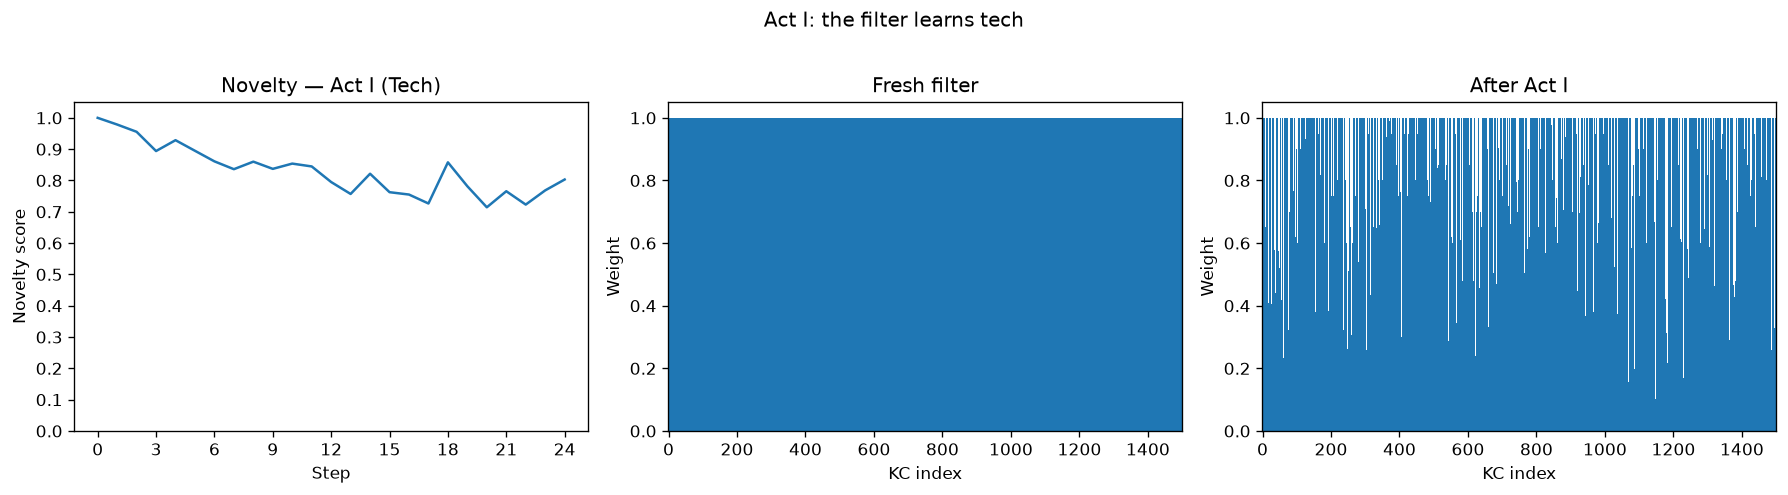

In [4]:
weights_fresh = f.weights().copy()
scores_I: list[float] = []
for vec in tech_emb:
    scores_I.append(f.novelty(vec))
    f.add(vec)
weights_after_I = f.weights().copy()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
plot_novelty_scores(scores_I, ax=axes[0])
axes[0].set_title("Novelty — Act I (Tech)")
plot_weight_state(weights_fresh, title="Fresh filter", ax=axes[1])
plot_weight_state(weights_after_I, title="After Act I", ax=axes[2])
plt.suptitle("Act I: the filter learns tech", y=1.02)
plt.tight_layout()
plt.show()

## § 4 — Act II: The Intruder

A single cuisine sentence arrives. The filter has never seen anything like it — novelty spikes.

In [5]:
spike_sentence = "Les pâtes al dente nécessitent une eau bien salée."
vec_spike = model.encode([spike_sentence], convert_to_numpy=True)[0].astype(np.float32)
score_spike = f.novelty(vec_spike)
print(f"Novelty of intruder: {score_spike:.3f}")
#don't add — just observe the score

Novelty of intruder: 0.883


## § 5 — Act III: Drift & Forgetting

25 cuisine sentences, with `tick()` after each. `tick()` applies passive weight recovery — the filter *forgets* what it hasn't seen recently. Tech memories fade; cuisine eventually becomes familiar.

In [6]:
#run a second filter without tick() for comparison
f_notick = FFBF(cfg)
for vec in tech_emb:
    f_notick.add(vec)

scores_III: list[float] = []
scores_III_notick: list[float] = []
weight_history: list[np.ndarray] = []

for vec in cuisine_emb:
    scores_III.append(f.novelty(vec))
    f.add(vec)
    f.tick()
    weight_history.append(f.weights().copy())

    scores_III_notick.append(f_notick.novelty(vec))
    f_notick.add(vec)

weights_after_III = f.weights().copy()
weight_history_arr = np.stack(weight_history)  #shape: (25, m)

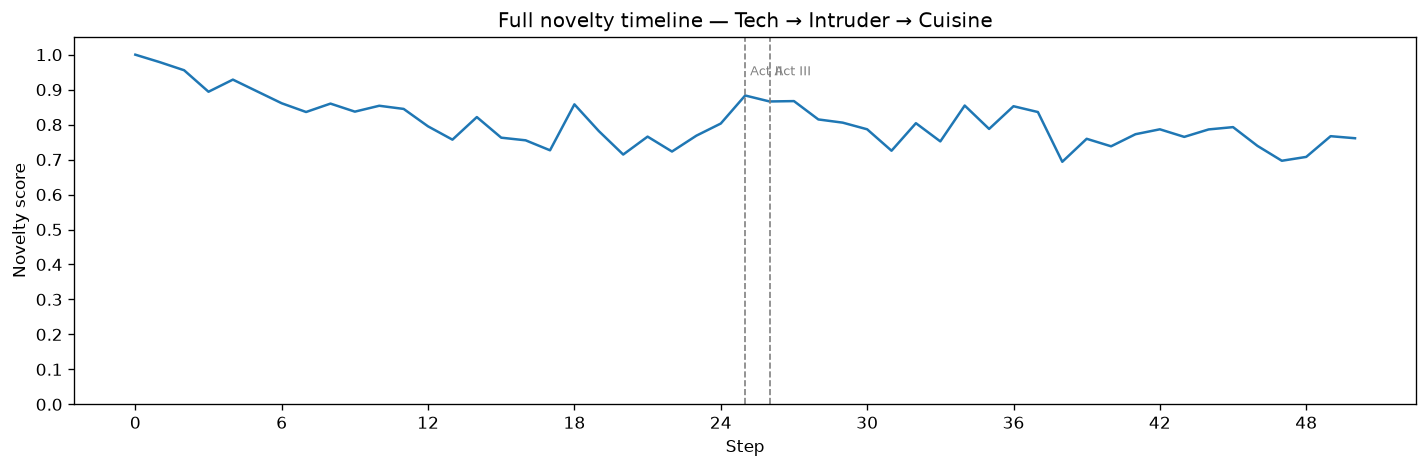

In [7]:
#full novelty timeline — all 3 acts
scores_all = scores_I + [score_spike] + scores_III
fig, ax = plt.subplots(figsize=(12, 4))
plot_novelty_scores(
    scores_all,
    phases=[(25, "Act II"), (26, "Act III")],
    ax=ax,
)
plt.title("Full novelty timeline — Tech → Intruder → Cuisine")
plt.tight_layout()
plt.show()

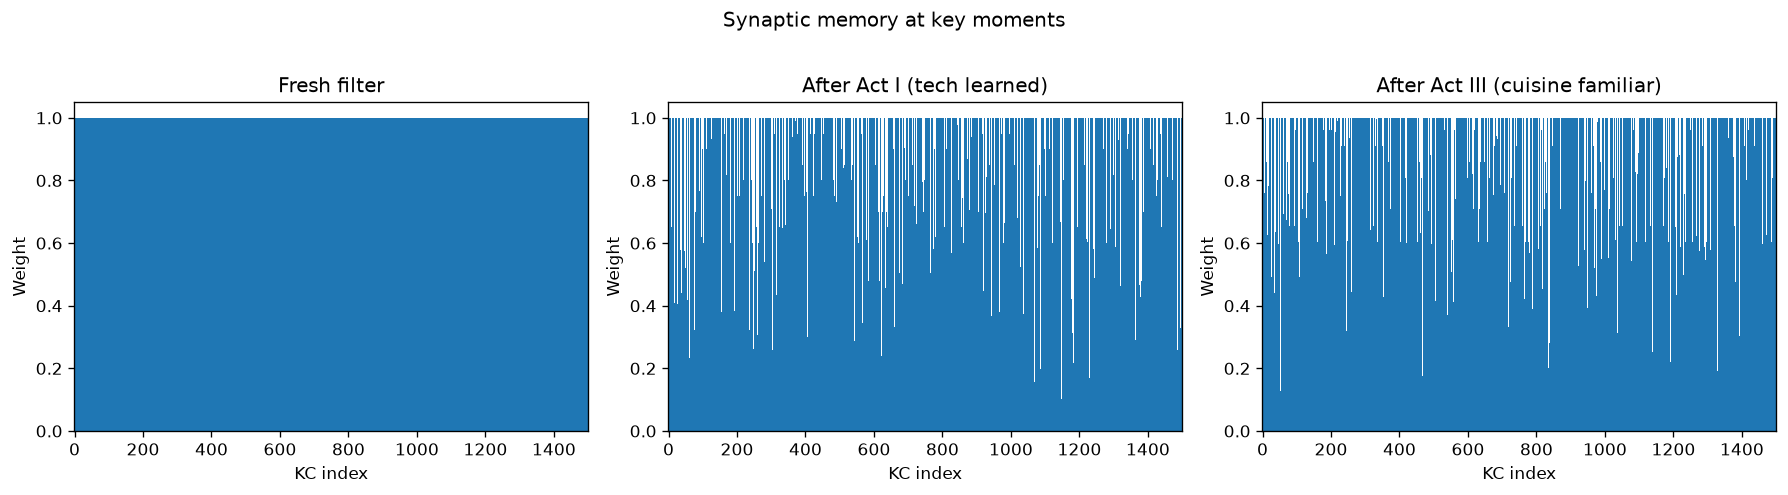

In [8]:
#weight snapshots at key moments
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
plot_weight_state(weights_fresh, title="Fresh filter", ax=axes[0])
plot_weight_state(weights_after_I, title="After Act I (tech learned)", ax=axes[1])
plot_weight_state(weights_after_III, title="After Act III (cuisine familiar)", ax=axes[2])
plt.suptitle("Synaptic memory at key moments", y=1.02)
plt.tight_layout()
plt.show()

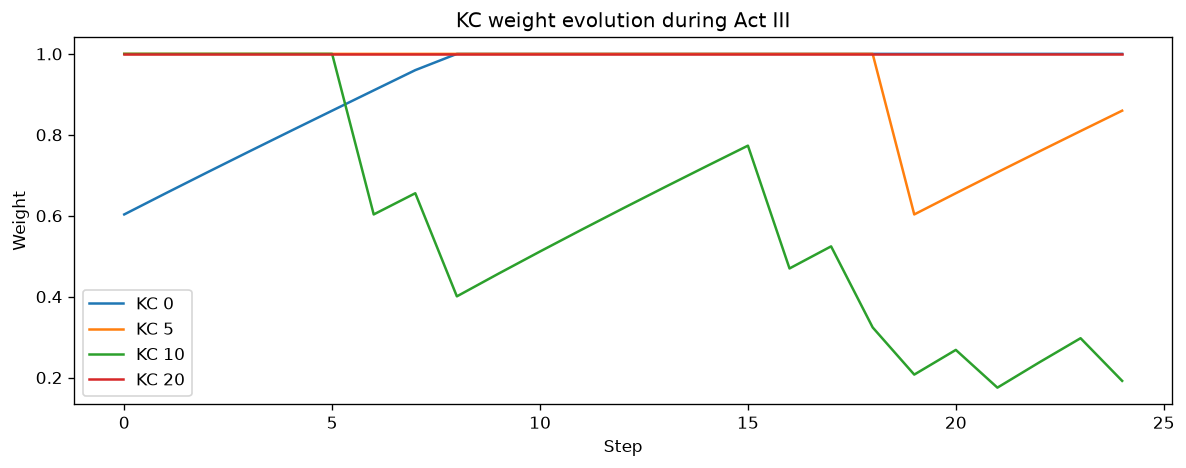

In [9]:
#weight evolution for 4 sampled KCs during Act III
fig, ax = plt.subplots(figsize=(10, 4))
plot_weight_evolution(weight_history_arr, indices=[0, 5, 10, 20], ax=ax)
ax.set_title("KC weight evolution during Act III")
plt.tight_layout()
plt.show()

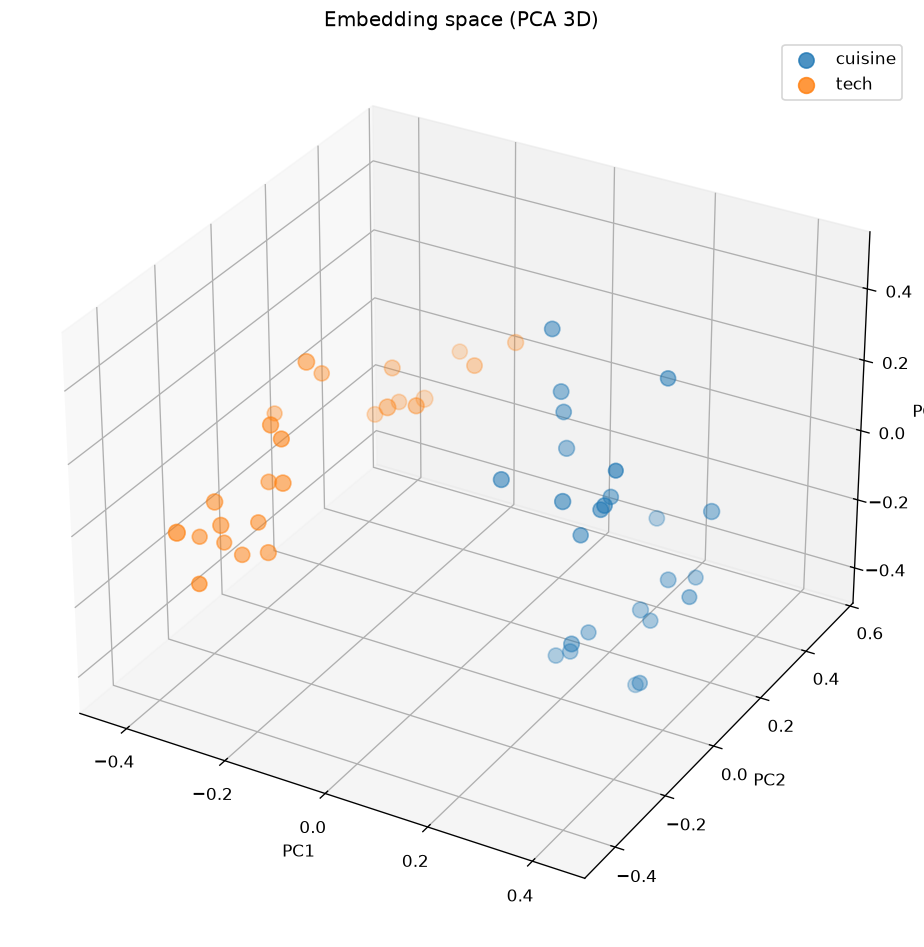

In [10]:
#3D embedding scatter — tech vs cuisine in PCA space
all_emb = np.vstack([tech_emb, cuisine_emb])
all_labels = ["tech"] * 25 + ["cuisine"] * 25
all_novelty = scores_I + scores_III

fig = plt.figure(figsize=(10, 8))
ax_3d = fig.add_subplot(projection="3d")
plot_embedding_3d(all_emb, all_labels, all_novelty, ax=ax_3d)
plt.tight_layout()
plt.show()

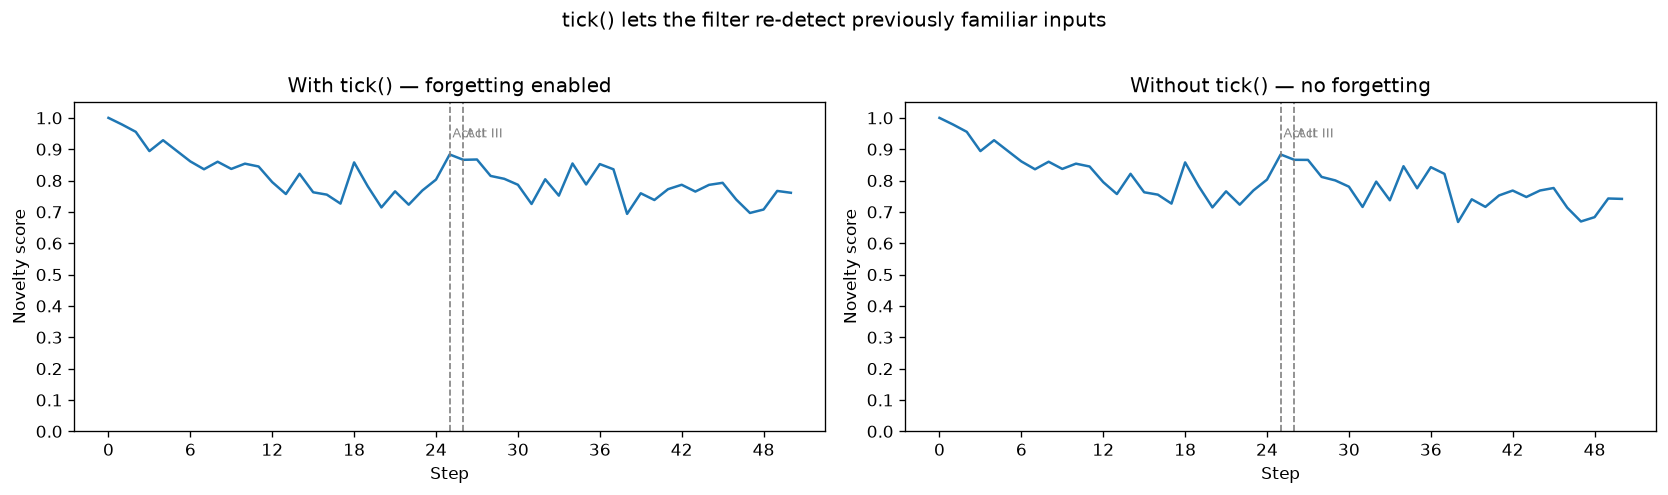

In [11]:
#with vs without tick() — side-by-side
scores_all_notick = scores_I + [score_spike] + scores_III_notick
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_novelty_scores(scores_all, phases=[(25, "Act II"), (26, "Act III")], ax=axes[0])
axes[0].set_title("With tick() — forgetting enabled")
plot_novelty_scores(scores_all_notick, phases=[(25, "Act II"), (26, "Act III")], ax=axes[1])
axes[1].set_title("Without tick() — no forgetting")
plt.suptitle("tick() lets the filter re-detect previously familiar inputs", y=1.02)
plt.tight_layout()
plt.show()

## § 6 — Going Further: Parameter Exploration

Each subsection replays the full scenario with a different hyperparameter configuration.

In [12]:
def run_scenario(override_cfg: FFBFConfig) -> tuple[list[float], list[float]]:
    """Run tech→cuisine scenario, returning (scores_tech, scores_cuisine)."""
    flocal = FFBF(override_cfg)
    s_tech: list[float] = []
    for vec in tech_emb:
        s_tech.append(flocal.novelty(vec))
        flocal.add(vec)
    s_cuisine: list[float] = []
    for vec in cuisine_emb:
        s_cuisine.append(flocal.novelty(vec))
        flocal.add(vec)
        flocal.tick()
    return s_tech, s_cuisine

### 6.1 Impact of `delta` — learning rate

Higher `delta` depresses active synapses faster → the filter learns sooner.

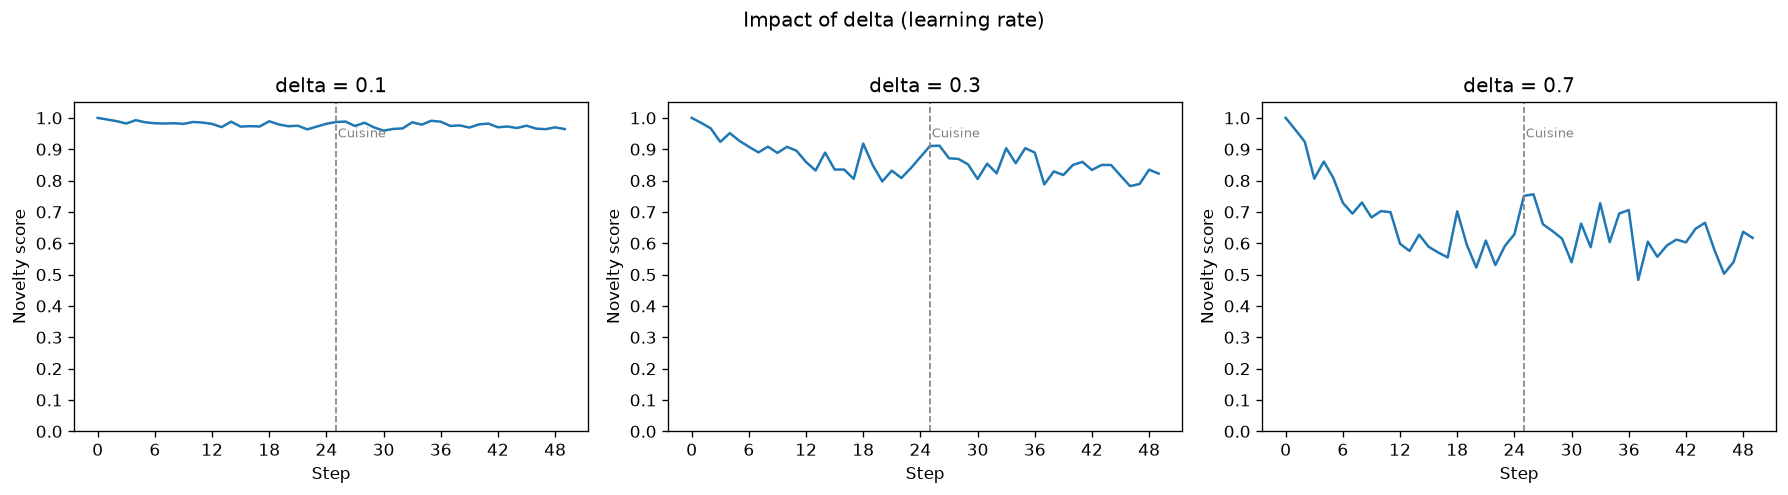

In [13]:
deltas = [0.1, 0.3, 0.7]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, d in zip(axes, deltas):
    c = FFBFConfig.default_for(input_dim=384, expected_n=50)
    c.delta = d
    c.decay_mode = DecayMode.EdgeAndFront
    c.tick_shape = TickShape.Exp
    c.tick_rate = 0.02
    c.seed = 42
    s_t, s_c = run_scenario(c)
    plot_novelty_scores(s_t + s_c, phases=[(25, "Cuisine")], ax=ax)
    ax.set_title(f"delta = {d}")
plt.suptitle("Impact of delta (learning rate)", y=1.02)
plt.tight_layout()
plt.show()

### 6.2 Impact of `tick_shape` — forgetting curve

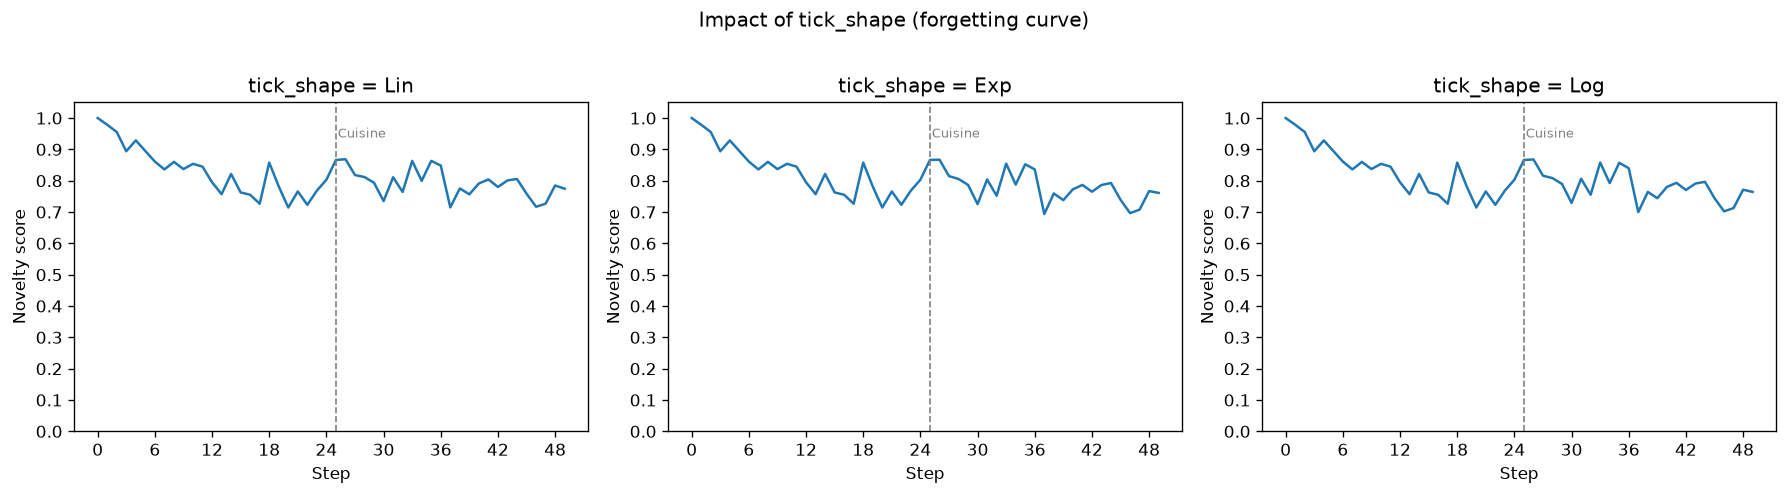

In [14]:
shapes = [TickShape.Lin, TickShape.Exp, TickShape.Log]
shape_names = ["Lin", "Exp", "Log"]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, shape, name in zip(axes, shapes, shape_names):
    c = FFBFConfig.default_for(input_dim=384, expected_n=50)
    c.delta = 0.4
    c.decay_mode = DecayMode.EdgeAndFront
    c.tick_shape = shape
    c.tick_rate = 0.02
    c.seed = 42
    s_t, s_c = run_scenario(c)
    plot_novelty_scores(s_t + s_c, phases=[(25, "Cuisine")], ax=ax)
    ax.set_title(f"tick_shape = {name}")
plt.suptitle("Impact of tick_shape (forgetting curve)", y=1.02)
plt.tight_layout()
plt.show()

### 6.3 Impact of `window_size` — adaptive threshold

`is_novel()` compares the current score against recent history. A smaller window reacts faster to score changes.

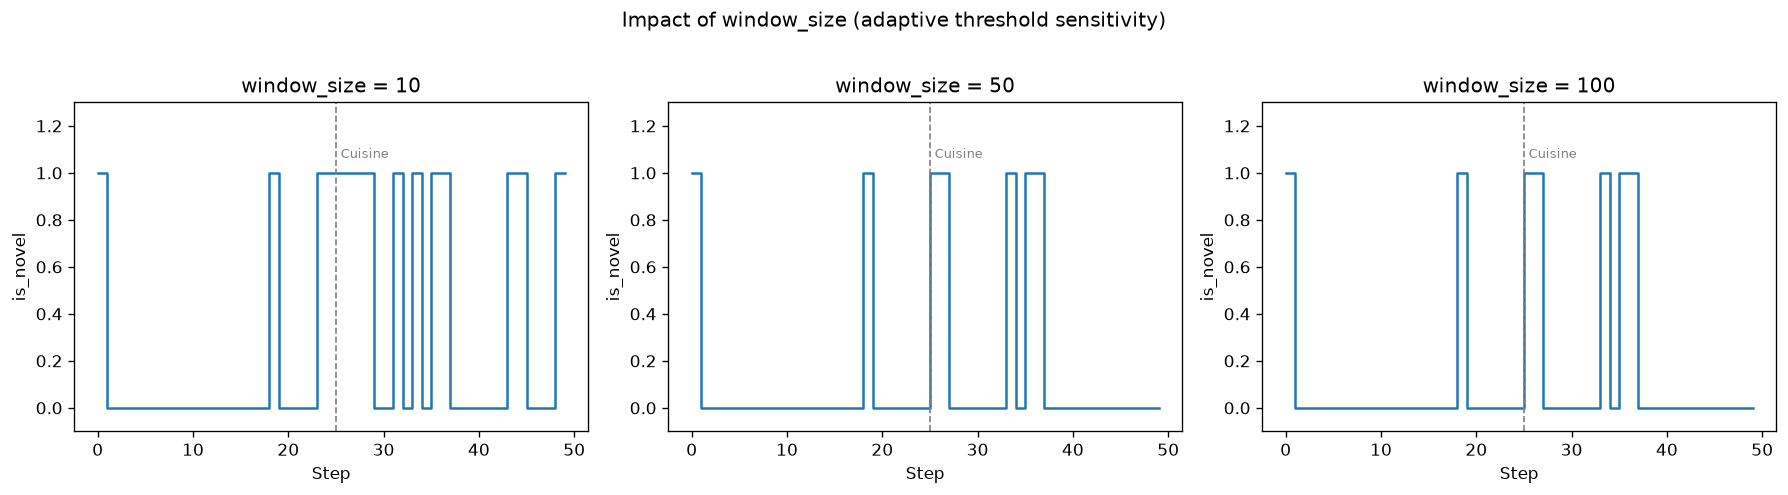

In [15]:
windows = [10, 50, 100]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, ws in zip(axes, windows):
    c = FFBFConfig.default_for(input_dim=384, expected_n=50)
    c.delta = 0.4
    c.decay_mode = DecayMode.EdgeAndFront
    c.tick_shape = TickShape.Exp
    c.tick_rate = 0.02
    c.window_size = ws
    c.seed = 42
    flocal = FFBF(c)
    novel_flags: list[int] = []
    for vec in np.vstack([tech_emb, cuisine_emb]):
        novel_flags.append(int(flocal.is_novel(vec, threshold=1.0)))
        flocal.add(vec)
        flocal.tick()
    ax.step(range(len(novel_flags)), novel_flags, where="post")
    ax.axvline(x=25, color="gray", linestyle="--", linewidth=1)
    ax.text(25.5, 1.05, "Cuisine", fontsize=8, color="gray", va="bottom")
    ax.set_xlabel("Step")
    ax.set_ylabel("is_novel")
    ax.set_ylim(-0.1, 1.3)
    ax.set_title(f"window_size = {ws}")
plt.suptitle("Impact of window_size (adaptive threshold sensitivity)", y=1.02)
plt.tight_layout()
plt.show()